<a href="https://colab.research.google.com/github/rsdina/Employee_Segmentation/blob/main/Employee_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HR Analytics Project: Employee Segmentation and Workforce Intelligence

## Step 1: Mount Google Drive and Setup
This cell mounts your Google Drive to access and save project files. It also imports necessary libraries like `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn` for data manipulation, visualization, and machine learning. Directories for data, results, models, and SQL queries are created to organize the project.

In [1]:
# Step 1: Mount Google Drive and Setup
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# IMPORTANT: Enable inline plotting
%matplotlib inline

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Mount Google Drive
drive.mount('/content/drive')

# Create directories in your Drive
import os
os.makedirs('/content/drive/MyDrive/HR_Analytics_Project/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/HR_Analytics_Project/results', exist_ok=True)
os.makedirs('/content/drive/MyDrive/HR_Analytics_Project/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/HR_Analytics_Project/sql', exist_ok=True)

print("Google Drive mounted and directories created!")

Mounted at /content/drive
Google Drive mounted and directories created!


## Step 2: Upload the Dataset
This cell prompts you to upload the `Employee_HR_data.csv` file, typically downloaded from Kaggle. Once uploaded, it saves the dataset to your Google Drive and loads it into a pandas DataFrame for further processing. It also prints the shape and the first few rows of the loaded data.

In [2]:
# Step 2: Upload the dataset from Kaggle
from google.colab import files

print("Please upload your employee_hr_data.csv file:")
uploaded = files.upload()

# Save to Drive
for filename in uploaded.keys():
    df = pd.read_csv(filename)
    df.to_csv(f'/content/drive/MyDrive/HR_Analytics_Project/data/{filename}', index=False)
    print(f"File saved: {filename}")

# Load the data
df = pd.read_csv('/content/drive/MyDrive/HR_Analytics_Project/data/Employee_HR_data.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Please upload your employee_hr_data.csv file:


Saving Employee_HR_data.csv to Employee_HR_data.csv
File saved: Employee_HR_data.csv
Dataset loaded successfully!
Shape: (14999, 11)


,EmpId,Satisfaction,Evaluation,number_of_projects,average_montly_hours,time_spent_company,work_accident,Promotion,Department,Salary_INR,Churn
0,780152,3.8,5.3,2,157,3,0,0,sales,11053,1
1,780153,8.0,8.6,5,262,6,0,0,sales,54063,1
2,780154,1.1,8.8,7,272,4,0,0,sales,61300,1
3,780155,7.2,8.7,5,223,5,0,0,sales,20647,1
4,780156,3.7,5.2,2,159,3,0,0,sales,17808,1


## Step 3: Data Cleaning and Feature Engineering
This step defines two functions:
- `clean_employee_data`: Handles duplicate entries, fills missing values (median for numeric, mode for categorical), cleans invalid age/salary entries, and standardizes categorical columns like 'Department'.
- `create_hr_features`: Maps original column names to standardized features (e.g., `Satisfaction` to `Employee_Satisfaction`), estimates missing key features (`Age`, `Training_Hours`, `Absenteeism_Days`), and derives new features like `Salary_Per_Experience`, `Overtime_Intensity`, `Engagement_Index`, and `Performance_Index` to enrich the dataset for analysis.

In [3]:
# Step 3: Data Cleaning Functions

def clean_employee_data(df):
    df_clean = df.copy()

    # Remove duplicates based on Employee ID
    if 'EmployeeID' in df_clean.columns:
        df_clean = df_clean.drop_duplicates(subset=['EmployeeID'])
    elif 'Employee_ID' in df_clean.columns:
        df_clean = df_clean.drop_duplicates(subset=['Employee_ID'])
    elif 'EmpId' in df_clean.columns: # Changed to 'EmpId' to match the actual column name
        df_clean = df_clean.drop_duplicates(subset=['EmpId'])

    # Handle missing values
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(include=['object']).columns

    for col in numeric_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

    # Handle invalid values
    if 'Age' in df_clean.columns:
        df_clean = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 80)]

    salary_cols = [col for col in df_clean.columns if 'salary' in col.lower() or 'compensation' in col.lower()]
    for col in salary_cols:
        if col in df_clean.columns:
            df_clean = df_clean[df_clean[col] > 0]

    # Standardize categorical columns
    for col in categorical_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].str.strip().str.title()

    # Standardize department names
    if 'Department' in df_clean.columns:
        dept_mapping = {
            'It': 'Information Technology',
            'Information Technology': 'Information Technology',
            'Hr': 'Human Resources',
            'Human Resource': 'Human Resources',
            'Human Resources': 'Human Resources',
            'Fin': 'Finance',
            'Finance': 'Finance',
            'Sales': 'Sales',
            'Marketing': 'Marketing',
            'Operations': 'Operations',
            'Engineering': 'Engineering',
            'R&D': 'Research and Development',
            'Research & Development': 'Research and Development'
        }
        df_clean['Department'] = df_clean['Department'].map(lambda x: dept_mapping.get(x, x))

    return df_clean

def create_hr_features(df):
    df_feat = df.copy()

    # Direct mapping of existing columns to standardized feature names
    if 'Satisfaction' in df_feat.columns:
        df_feat['Employee_Satisfaction'] = df_feat['Satisfaction'] # Normalize to 0-1 range later if needed
    if 'Evaluation' in df_feat.columns:
        df_feat['Performance_Rating'] = df_feat['Evaluation'] # Normalize to 0-1 range later if needed
    if 'time_spent_company' in df_feat.columns:
        df_feat['Company_Tenure'] = df_feat['time_spent_company']
    if 'Salary_INR' in df_feat.columns:
        df_feat['Annual_Salary'] = df_feat['Salary_INR']
    if 'average_montly_hours' in df_feat.columns:
        df_feat['Overtime_Hours'] = df_feat['average_montly_hours']
    if 'Churn' in df_feat.columns:
        df_feat['Attrition'] = df_feat['Churn']

    # Add placeholder/estimated columns if not present in raw data
    # These columns are often found in HR datasets but are missing from the uploaded CSV
    if 'Age' not in df_feat.columns:
        # Estimate Age based on company tenure, assuming employees start around 25
        df_feat['Age'] = df_feat['Company_Tenure'] + 25
    if 'Training_Hours' not in df_feat.columns:
        # Placeholder: assume training hours are proportional to number of projects
        df_feat['Training_Hours'] = df_feat['number_of_projects'] * 5 # Example estimation
    if 'Absenteeism_Days' not in df_feat.columns:
        # Placeholder: assume some absenteeism based on overtime intensity
        df_feat['Absenteeism_Days'] = (df_feat['Overtime_Hours'] / 160 * 2).clip(upper=10) # Max 10 days

    # Derived features
    # Salary per experience
    if 'Annual_Salary' in df_feat.columns and 'Company_Tenure' in df_feat.columns:
        df_feat['Salary_Per_Experience'] = df_feat['Annual_Salary'] / (df_feat['Company_Tenure'] + 1)

    # Overtime Intensity (assuming 160 hours is standard monthly full-time)
    if 'Overtime_Hours' in df_feat.columns:
        df_feat['Overtime_Intensity'] = df_feat['Overtime_Hours'] / 160.0

    # Engagement Index (normalize Employee_Satisfaction if it's not already 0-1)
    if 'Employee_Satisfaction' in df_feat.columns:
        min_val = df_feat['Employee_Satisfaction'].min()
        max_val = df_feat['Employee_Satisfaction'].max()
        if max_val > min_val:
            df_feat['Engagement_Index'] = (df_feat['Employee_Satisfaction'] - min_val) / (max_val - min_val)
        else:
            df_feat['Engagement_Index'] = df_feat['Employee_Satisfaction'] # All values are the same

    # Performance Index (normalize Performance_Rating if it's not already 0-1)
    if 'Performance_Rating' in df_feat.columns:
        min_val = df_feat['Performance_Rating'].min()
        max_val = df_feat['Performance_Rating'].max()
        if max_val > min_val:
            df_feat['Performance_Index'] = (df_feat['Performance_Rating'] - min_val) / (max_val - min_val)
        else:
            df_feat['Performance_Index'] = df_feat['Performance_Rating'] # All values are the same

    return df_feat

# Apply cleaning and feature engineering
df_clean = clean_employee_data(df)
df_feat = create_hr_features(df_clean)

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)
print("Features Added:", [col for col in df_feat.columns if col not in df_clean.columns])
print("\nFirst few rows after feature engineering:")
df_feat.head()


Original Shape: (14999, 11)
Cleaned Shape: (14999, 11)
Features Added: ['Employee_Satisfaction', 'Performance_Rating', 'Company_Tenure', 'Annual_Salary', 'Overtime_Hours', 'Attrition', 'Age', 'Training_Hours', 'Absenteeism_Days', 'Salary_Per_Experience', 'Overtime_Intensity', 'Engagement_Index', 'Performance_Index']

First few rows after feature engineering:


,EmpId,Satisfaction,Evaluation,number_of_projects,average_montly_hours,time_spent_company,work_accident,Promotion,Department,Salary_INR,...,Annual_Salary,Overtime_Hours,Attrition,Age,Training_Hours,Absenteeism_Days,Salary_Per_Experience,Overtime_Intensity,Engagement_Index,Performance_Index
0,780152,3.8,5.3,2,157,3,0,0,Sales,11053,...,11053,157,1,28,10,1.9625,2763.250000,0.98125,0.318681,0.265625
1,780153,8.0,8.6,5,262,6,0,0,Sales,54063,...,54063,262,1,31,25,3.2750,7723.285714,1.63750,0.780220,0.781250
2,780154,1.1,8.8,7,272,4,0,0,Sales,61300,...,61300,272,1,29,35,3.4000,12260.000000,1.70000,0.021978,0.812500
3,780155,7.2,8.7,5,223,5,0,0,Sales,20647,...,20647,223,1,30,25,2.7875,3441.166667,1.39375,0.692308,0.796875
4,780156,3.7,5.2,2,159,3,0,0,Sales,17808,...,17808,159,1,28,10,1.9875,4452.000000,0.99375,0.307692,0.250000


## Step 4: Exploratory Data Analysis (EDA) - Distribution Analysis
This cell provides an overview of the workforce, including total employees, average salary, age, tenure, and attrition rate. It then generates and displays a series of distribution plots for key HR metrics such as Age, Salary, Tenure, Performance Rating, Employee Satisfaction, and Attrition. These plots help understand the spread and patterns within the data. The combined plot is saved to Google Drive.

Workforce Overview
Total Employees: 14,999
Average Salary: $62,742.70
Average Age: 28.5 years
Average Tenure: 3.5 years
Attrition Rate: 23.8%


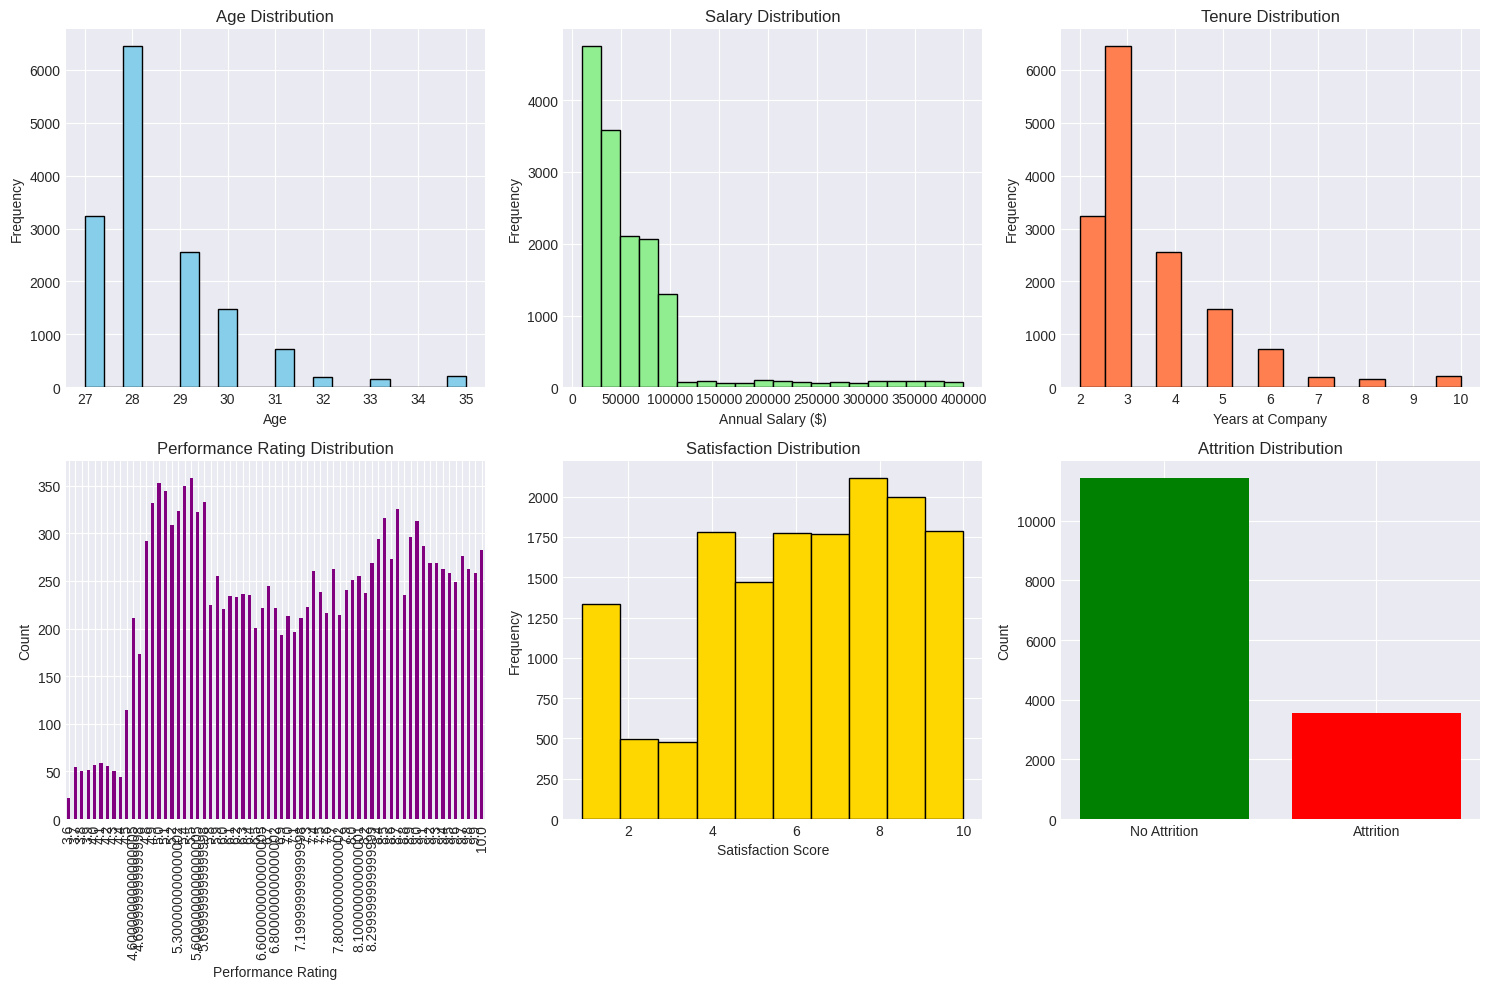

Distribution analysis image displayed above and saved to Drive.


In [4]:
# Step 4: Exploratory Data Analysis

from IPython.display import display

# Overview Metrics
print("Workforce Overview")
print("=" * 50)
print(f"Total Employees: {len(df_feat):,}")
if 'Annual_Salary' in df_feat.columns:
    print(f"Average Salary: ${df_feat['Annual_Salary'].mean():,.2f}")
if 'Age' in df_feat.columns:
    print(f"Average Age: {df_feat['Age'].mean():.1f} years") # Added ' years' for consistency
if 'Company_Tenure' in df_feat.columns:
    print(f"Average Tenure: {df_feat['Company_Tenure'].mean():.1f} years")
if 'Attrition' in df_feat.columns:
    print(f"Attrition Rate: {df_feat['Attrition'].mean()*100:.1f}%")

# Distribution Plots
fig_multi, axes_multi = plt.subplots(2, 3, figsize=(15, 10)) # Renamed fig to fig_multi, axes to axes_multi for clarity

# Age Distribution
if 'Age' in df_feat.columns:
    df_feat['Age'].hist(bins=20, ax=axes_multi[0,0], color='skyblue', edgecolor='black')
    axes_multi[0,0].set_title('Age Distribution')
    axes_multi[0,0].set_xlabel('Age')
    axes_multi[0,0].set_ylabel('Frequency')

# Salary Distribution
if 'Annual_Salary' in df_feat.columns:
    df_feat['Annual_Salary'].hist(bins=20, ax=axes_multi[0,1], color='lightgreen', edgecolor='black')
    axes_multi[0,1].set_title('Salary Distribution')
    axes_multi[0,1].set_xlabel('Annual Salary ($)')
    axes_multi[0,1].set_ylabel('Frequency')

# Tenure Distribution
if 'Company_Tenure' in df_feat.columns:
    df_feat['Company_Tenure'].hist(bins=15, ax=axes_multi[0,2], color='coral', edgecolor='black')
    axes_multi[0,2].set_title('Tenure Distribution')
    axes_multi[0,2].set_xlabel('Years at Company')
    axes_multi[0,2].set_ylabel('Frequency')

# Performance Distribution
if 'Performance_Rating' in df_feat.columns:
    df_feat['Performance_Rating'].value_counts().sort_index().plot(kind='bar', ax=axes_multi[1,0], color='purple')
    axes_multi[1,0].set_title('Performance Rating Distribution')
    axes_multi[1,0].set_xlabel('Performance Rating')
    axes_multi[1,0].set_ylabel('Count')

# Satisfaction Distribution
if 'Employee_Satisfaction' in df_feat.columns:
    df_feat['Employee_Satisfaction'].hist(bins=10, ax=axes_multi[1,1], color='gold', edgecolor='black')
    axes_multi[1,1].set_title('Satisfaction Distribution')
    axes_multi[1,1].set_xlabel('Satisfaction Score')
    axes_multi[1,1].set_ylabel('Frequency')

# Attrition Distribution
if 'Attrition' in df_feat.columns:
    attrition_counts = df_feat['Attrition'].value_counts()
    axes_multi[1,2].bar(['No Attrition', 'Attrition'], attrition_counts.values, color=['green', 'red'])
    axes_multi[1,2].set_title('Attrition Distribution')
    axes_multi[1,2].set_ylabel('Count')

plt.tight_layout()

# Save to Drive
plt.savefig('/content/drive/MyDrive/HR_Analytics_Project/results/distribution_analysis.png', dpi=300, bbox_inches='tight')

# Display in Colab
display(fig_multi) # Explicitly display the figure object
plt.close(fig_multi) # Close the figure after displaying to free memory
print("Distribution analysis image displayed above and saved to Drive.")

# Removed the redundant individual age plot to streamline output.

## Step 5: Department Analysis
This cell performs an in-depth analysis of HR metrics grouped by department. It calculates the number of employees, average salary, performance, satisfaction, and attrition rate for each department. The results are displayed in a table and visualized through bar plots, offering insights into departmental strengths and weaknesses. The generated plots are saved to Google Drive.

Department Metrics:


,Employees,Avg_Salary,Avg_Performance,Avg_Satisfaction,Attrition_Rate
Department,,,,,
Accounting,767,66954.46,7.18,5.82,0.27
Human Resources,739,61286.95,7.09,5.99,0.29
Information Technology,1227,60491.40,7.17,6.18,0.22
Management,630,119738.03,7.24,6.21,0.14
Marketing,858,66492.66,7.16,6.19,0.24
Product_Mng,902,59912.76,7.15,6.20,0.22
Randd,787,59962.47,7.12,6.20,0.15
Sales,4140,58828.95,7.10,6.14,0.24
Support,2229,57993.37,7.23,6.18,0.25


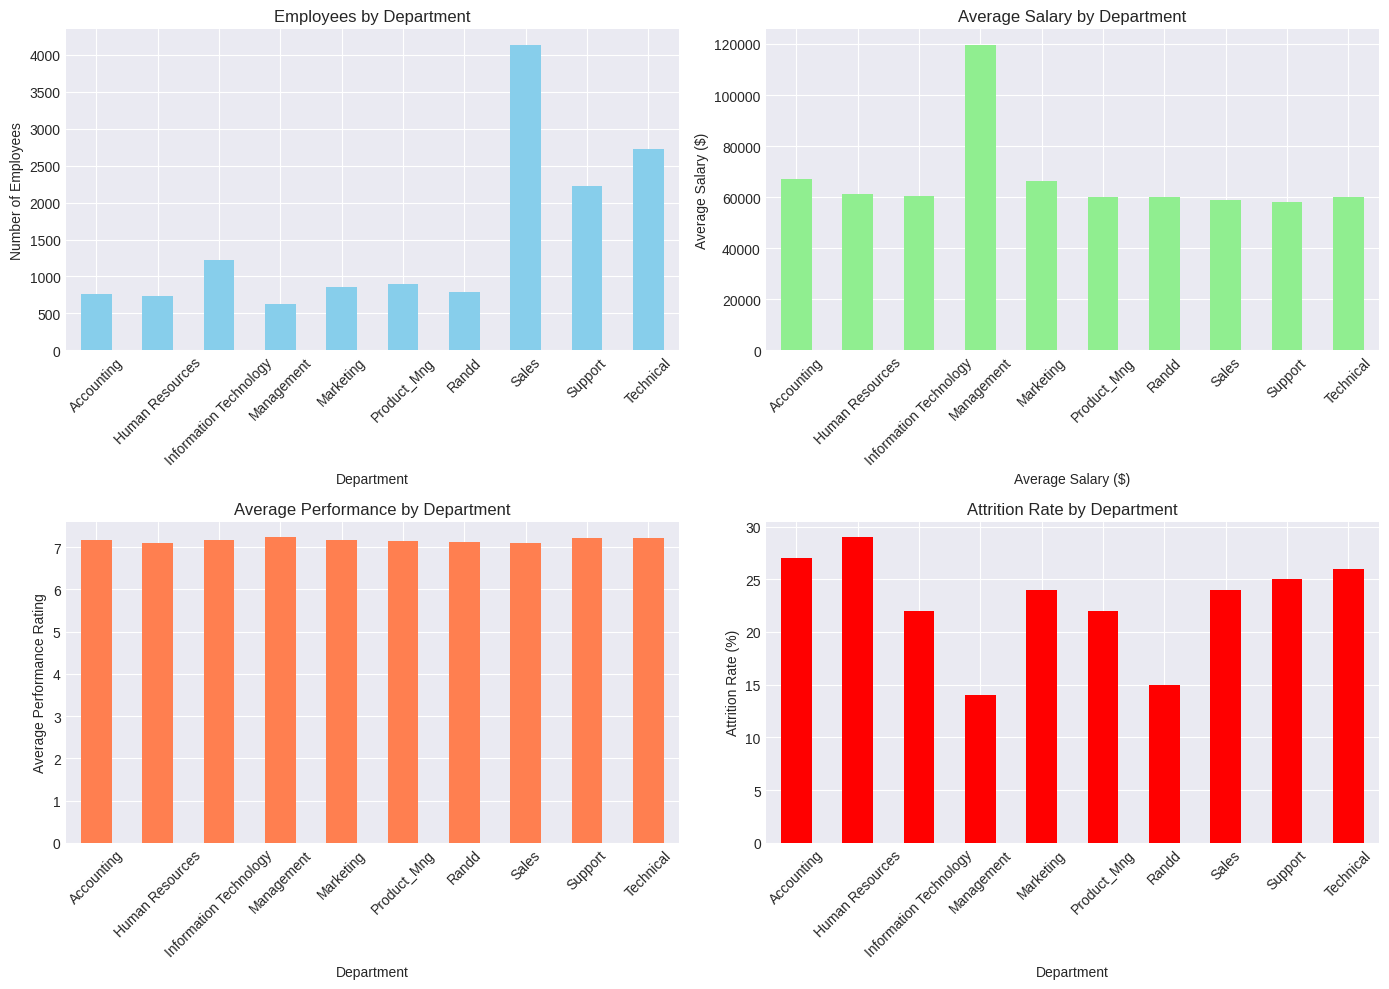

Departmental analysis image displayed above and saved to Drive.


In [5]:
# Step 5: Department Analysis
if 'Department' in df_feat.columns and 'Annual_Salary' in df_feat.columns:
    dept_metrics = df_feat.groupby('Department').agg({
        'EmpId': 'count', # Corrected column name for counting employees
        'Annual_Salary': 'mean',
        'Performance_Rating': 'mean',
        'Employee_Satisfaction': 'mean',
        'Attrition': 'mean'
    }).round(2)

    dept_metrics.columns = ['Employees', 'Avg_Salary', 'Avg_Performance', 'Avg_Satisfaction', 'Attrition_Rate']
    print("Department Metrics:")
    display(dept_metrics)  # Using display() for better Colab output

    # Visualize Department Metrics
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    dept_metrics['Employees'].plot(kind='bar', ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Employees by Department')
    axes[0,0].set_xlabel('Department')
    axes[0,0].set_ylabel('Number of Employees')
    axes[0,0].tick_params(axis='x', rotation=45)

    dept_metrics['Avg_Salary'].plot(kind='bar', ax=axes[0,1], color='lightgreen')
    axes[0,1].set_title('Average Salary by Department')
    axes[0,1].set_xlabel('Average Salary ($)')
    axes[0,1].set_ylabel('Average Salary ($)') # Added y-label
    axes[0,1].tick_params(axis='x', rotation=45)

    dept_metrics['Avg_Performance'].plot(kind='bar', ax=axes[1,0], color='coral')
    axes[1,0].set_title('Average Performance by Department')
    axes[1,0].set_xlabel('Department')
    axes[1,0].set_ylabel('Average Performance Rating')
    axes[1,0].tick_params(axis='x', rotation=45)

    (dept_metrics['Attrition_Rate'] * 100).plot(kind='bar', ax=axes[1,1], color='red')
    axes[1,1].set_title('Attrition Rate by Department')
    axes[1,1].set_xlabel('Department')
    axes[1,1].set_ylabel('Attrition Rate (%)')
    axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/HR_Analytics_Project/results/department_analysis.png', dpi=300, bbox_inches='tight')
    display(fig) # Explicitly display the figure object
    plt.close(fig) # Close the figure after displaying to free memory
    print("Departmental analysis image displayed above and saved to Drive.") # Added confirmation message

## Step 6: Correlation Heatmap
This cell computes and visualizes the correlation matrix between various numeric HR metrics (e.g., Age, Annual Salary, Employee Satisfaction). A heatmap is used to graphically represent these correlations, helping to identify relationships and dependencies between different employee attributes. The heatmap is saved to Google Drive.

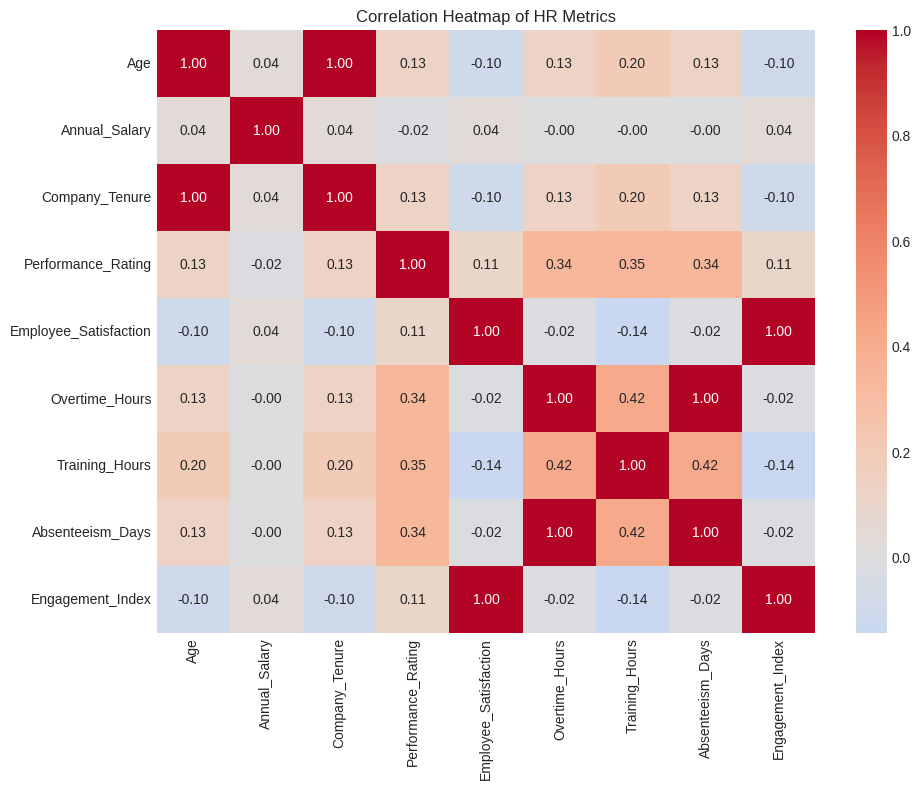

In [6]:
# Step 6: Correlation Heatmap
numeric_cols = ['Age', 'Annual_Salary', 'Company_Tenure', 'Performance_Rating',
                'Employee_Satisfaction', 'Overtime_Hours', 'Training_Hours',
                'Absenteeism_Days', 'Engagement_Index']

numeric_cols_exist = [col for col in numeric_cols if col in df_feat.columns]

if len(numeric_cols_exist) > 1:
    corr_matrix = df_feat[numeric_cols_exist].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Heatmap of HR Metrics')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/HR_Analytics_Project/results/correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()  # This will display in Colab

## Step 7: Employee Segmentation - Optimal K Identification
This step focuses on preparing data for clustering. It selects relevant features, handles any remaining missing values by filling them with the median, and applies `RobustScaler` for feature scaling due to the presence of outliers. It then uses the Elbow Method and Silhouette Score to determine the optimal number of clusters (K) for employee segmentation. The evaluation plots are saved to Google Drive, and the selected optimal K is printed.

Selected Features for Clustering: ['Age', 'Annual_Salary', 'Company_Tenure', 'Performance_Rating', 'Employee_Satisfaction', 'Overtime_Hours', 'number_of_projects', 'Training_Hours', 'Absenteeism_Days', 'Engagement_Index', 'Performance_Index']
Feature Matrix Shape: (14999, 11)
Dataset contains outliers: True
Using RobustScaler due to outliers


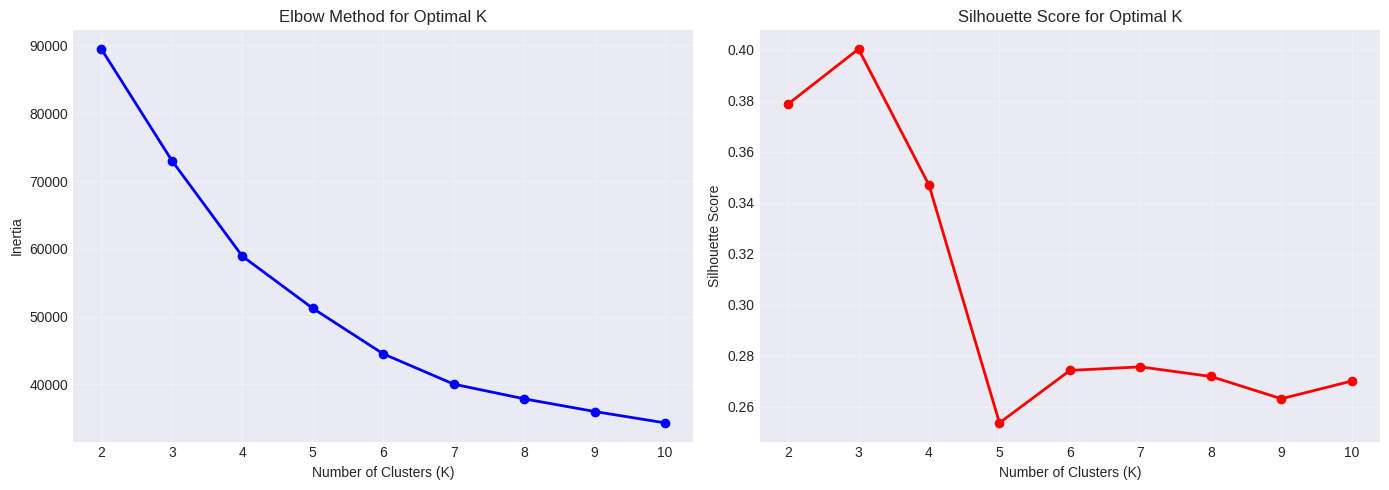

K-Means Clustering Evaluation:
K=2: Inertia=89475.03, Silhouette=0.379
K=3: Inertia=73030.78, Silhouette=0.400
K=4: Inertia=58919.68, Silhouette=0.347
K=5: Inertia=51224.53, Silhouette=0.254
K=6: Inertia=44508.35, Silhouette=0.274
K=7: Inertia=40043.91, Silhouette=0.276
K=8: Inertia=37875.36, Silhouette=0.272
K=9: Inertia=36005.92, Silhouette=0.263
K=10: Inertia=34326.59, Silhouette=0.270

Selected Optimal K: 4


In [7]:
# Step 7: Employee Segmentation

# Select features for clustering
clustering_features = []

# Update feature_candidates to reflect the actual column names in df_feat
# after feature engineering in the previous step
feature_candidates_list = [
    'Age',
    'Annual_Salary',
    'Company_Tenure',
    'Performance_Rating',
    'Employee_Satisfaction',
    'Overtime_Hours',
    'number_of_projects', # This is an original numeric column and seems relevant
    'Training_Hours',
    'Absenteeism_Days',
    'Engagement_Index',
    'Performance_Index'
]

for feature in feature_candidates_list:
    if feature in df_feat.columns:
        clustering_features.append(feature)

print("Selected Features for Clustering:", clustering_features)

# Create feature matrix
X = df_feat[clustering_features].copy()
X = X.fillna(X.median()) # Fill any remaining NaNs after feature creation
print(f"Feature Matrix Shape: {X.shape}")

# Feature Scaling
def check_outliers(data):
    outlier_count = 0
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((data[col] < (Q1 - 1.5 * IQR)) | (data[col] > (Q3 + 1.5 * IQR))).sum()
        outlier_count += outliers
    return outlier_count > 0

has_outliers = check_outliers(X)
print(f"Dataset contains outliers: {has_outliers}")

if has_outliers:
    scaler = RobustScaler()
    print("Using RobustScaler due to outliers")
else:
    scaler = StandardScaler()
    print("Using StandardScaler")

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Find optimal K
def find_optimal_clusters(data, max_k=10):
    inertias = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(data, kmeans.labels_))

    return k_range, inertias, silhouette_scores

k_range, inertias, silhouette_scores = find_optimal_clusters(X_scaled, max_k=10)

# Plot Elbow and Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HR_Analytics_Project/results/optimal_clusters_analysis.png', dpi=300, bbox_inches='tight')
plt.show()  # This will display in Colab

# Print results
print("K-Means Clustering Evaluation:")
print("=" * 50)
for k, inertia, silhouette in zip(k_range, inertias, silhouette_scores):
    print(f"K={k}: Inertia={inertia:.2f}, Silhouette={silhouette:.3f}")

# Based on results, choose optimal K
optimal_k = 4
print(f"\nSelected Optimal K: {optimal_k}")

## Step 8: Cluster Profiling
After determining the optimal number of clusters, this cell trains the final K-Means model. It assigns each employee to a cluster and then profiles these clusters by calculating the mean of various HR metrics for each segment. Human-readable segment names are assigned based on these profiles (e.g., 'High Performers', 'Retention Risk'). The cluster distribution, profile, and segment names are printed, and the segment mapping is saved to Google Drive.

In [8]:
# Step 8: Cluster Profiling

# Train final model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_feat['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster Distribution:")
print(df_feat['Cluster'].value_counts().sort_index())
print("\nCluster Percentages:")
print((df_feat['Cluster'].value_counts().sort_index() / len(df_feat) * 100).round(1))

# Cluster Profiling
cluster_profile = df_feat.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual_Salary': 'mean',
    'Company_Tenure': 'mean',
    'Performance_Rating': 'mean',
    'Employee_Satisfaction': 'mean',
    'Overtime_Hours': 'mean',
    'Training_Hours': 'mean',
    'Absenteeism_Days': 'mean',
    'Attrition': 'mean',
    'Engagement_Index': 'mean',
    'Performance_Index': 'mean'
}).round(2)

print("\nCluster Profile:")
display(cluster_profile)

# Assign Segment Names
segment_names = {}
for cluster in cluster_profile.index:
    row = cluster_profile.loc[cluster]
    engagement = row.get('Engagement_Index', row.get('Employee_Satisfaction', 0))
    performance = row.get('Performance_Index', row.get('Performance_Rating', 0))
    attrition = row.get('Attrition', 0)
    tenure = row.get('Company_Tenure', 0)
    overtime = row.get('Overtime_Hours', 0)

    if engagement > 0.7 and performance > 0.7:
        segment_names[cluster] = 'High Performers'
    elif engagement > 0.6 and tenure < 3:
        segment_names[cluster] = 'Emerging Talent'
    elif engagement < 0.4 and attrition > 0.2:
        segment_names[cluster] = 'Retention Risk'
    elif engagement < 0.5 and performance < 0.5:
        segment_names[cluster] = 'Disengaged Employees'
    elif engagement < 0.5:
        segment_names[cluster] = 'Needs Improvement'
    else:
        segment_names[cluster] = 'Stable Employees'

df_feat['Segment'] = df_feat['Cluster'].map(segment_names)
print("\nSegment Names:")
for cluster, name in segment_names.items():
    print(f"Cluster {cluster}: {name}")

# Save the segment mapping
segment_df = pd.DataFrame({
    'Cluster': list(segment_names.keys()),
    'Segment': list(segment_names.values())
})
segment_df.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/segment_mapping.csv', index=False)


Cluster Distribution:
Cluster
0     563
1    9368
2     844
3    4224
Name: count, dtype: int64

Cluster Percentages:
Cluster
0     3.8
1    62.5
2     5.6
3    28.2
Name: count, dtype: float64

Cluster Profile:


,Age,Annual_Salary,Company_Tenure,Performance_Rating,Employee_Satisfaction,Overtime_Hours,Training_Hours,Absenteeism_Days,Attrition,Engagement_Index,Performance_Index
Cluster,,,,,,,,,,,
0,33.43,94447.93,8.43,7.10,6.51,198.02,18.83,2.48,0.00,0.62,0.55
1,27.71,47652.77,2.71,6.82,6.52,189.61,17.08,2.37,0.17,0.62,0.50
2,28.10,287173.56,3.10,7.04,6.43,200.74,18.93,2.51,0.07,0.61,0.54
3,29.66,47139.67,4.66,7.96,5.15,226.88,23.35,2.84,0.45,0.47,0.68



Segment Names:
Cluster 0: Stable Employees
Cluster 1: Emerging Talent
Cluster 2: Stable Employees
Cluster 3: Needs Improvement


## Step 9: PCA Visualization
This cell performs Principal Component Analysis (PCA) to reduce the dimensionality of the clustered data to two components. It then visualizes the employee segments in a 2D scatter plot, where each point represents an employee, colored by their assigned segment. This visualization helps to visually understand the separation and characteristics of the identified segments. The PCA plot is saved to Google Drive.

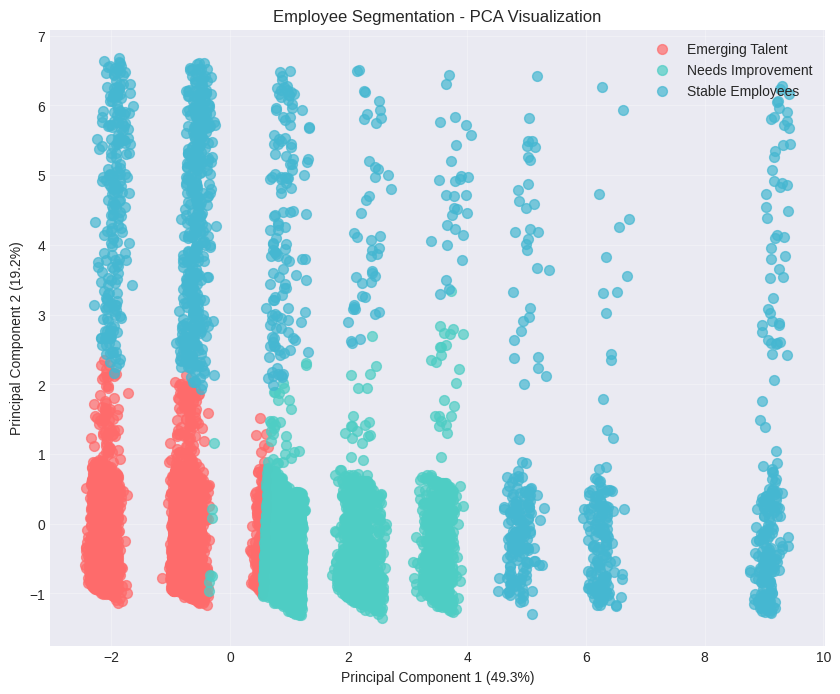

PCA Explained Variance Ratio: [0.4932643  0.19220761]


In [9]:
# Step 9: PCA Visualization

# Ensure 'Segment' column is present, re-map if necessary
# This addresses a potential KeyError if the segment mapping from the previous cell didn't persist correctly
if 'Cluster' in df_feat.columns and 'Segment' not in df_feat.columns:
    df_feat['Segment'] = df_feat['Cluster'].map(segment_names)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Segment': df_feat['Segment']
})

plt.figure(figsize=(10, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
unique_segments = pca_df['Segment'].unique()
for i, segment in enumerate(unique_segments):
    mask = pca_df['Segment'] == segment
    plt.scatter(pca_df.loc[mask, 'PCA1'], pca_df.loc[mask, 'PCA2'],
                label=segment, alpha=0.7, s=50, c=colors[i % len(colors)])

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Employee Segmentation - PCA Visualization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/content/drive/MyDrive/HR_Analytics_Project/results/pca_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()  # This will display in Colab

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")

## Step 10: Segment Analysis
This cell provides a detailed statistical and visual analysis of the identified employee segments. It calculates and displays descriptive statistics (mean and standard deviation) for key HR metrics within each segment. Additionally, it generates a series of bar charts to visualize segment distribution, average salary, engagement, performance, attrition rate, and training hours across different segments. These visualizations are saved to Google Drive.

Detailed Segment Analysis:


Age       Annual_Salary            Company_Tenure        \
                    mean   std          mean        std           mean   std   
Segment                                                                        
Emerging Talent    27.71  0.52      47652.77   28661.27           2.71  0.52   
Needs Improvement  29.66  0.74      47139.67   29829.39           4.66  0.74   
Stable Employees   30.23  2.84     210055.91  122648.16           5.23  2.84   

                  Performance_Rating       Employee_Satisfaction        \
                                mean   std                  mean   std   
Segment                                                                  
Emerging Talent                 6.82  1.65                  6.52  2.04   
Needs Improvement               7.96  1.62                  5.15  3.12   
Stable Employees                7.06  1.59                  6.46  2.24   

                  Overtime_Hours        Training_Hours       Absenteeism_Days  \
                            mean    std           mean   std             mean   
Segment                                                                         
Emerging Talent           189.61  45.73          17.08  5.23             2.37   
Needs Improvement         226.88  50.00          23.35  6.16             2.84   
Stable Employees          199.65  47.81          18.89  5.23             2.50   

                        Attrition        
                    std      mean   std  
Segment                                  
Emerging Talent    0.57      0.17  0.38  
Needs Improvement  0.63      0.45  0.50  
Stable Employees   0.60      0.04  0.19

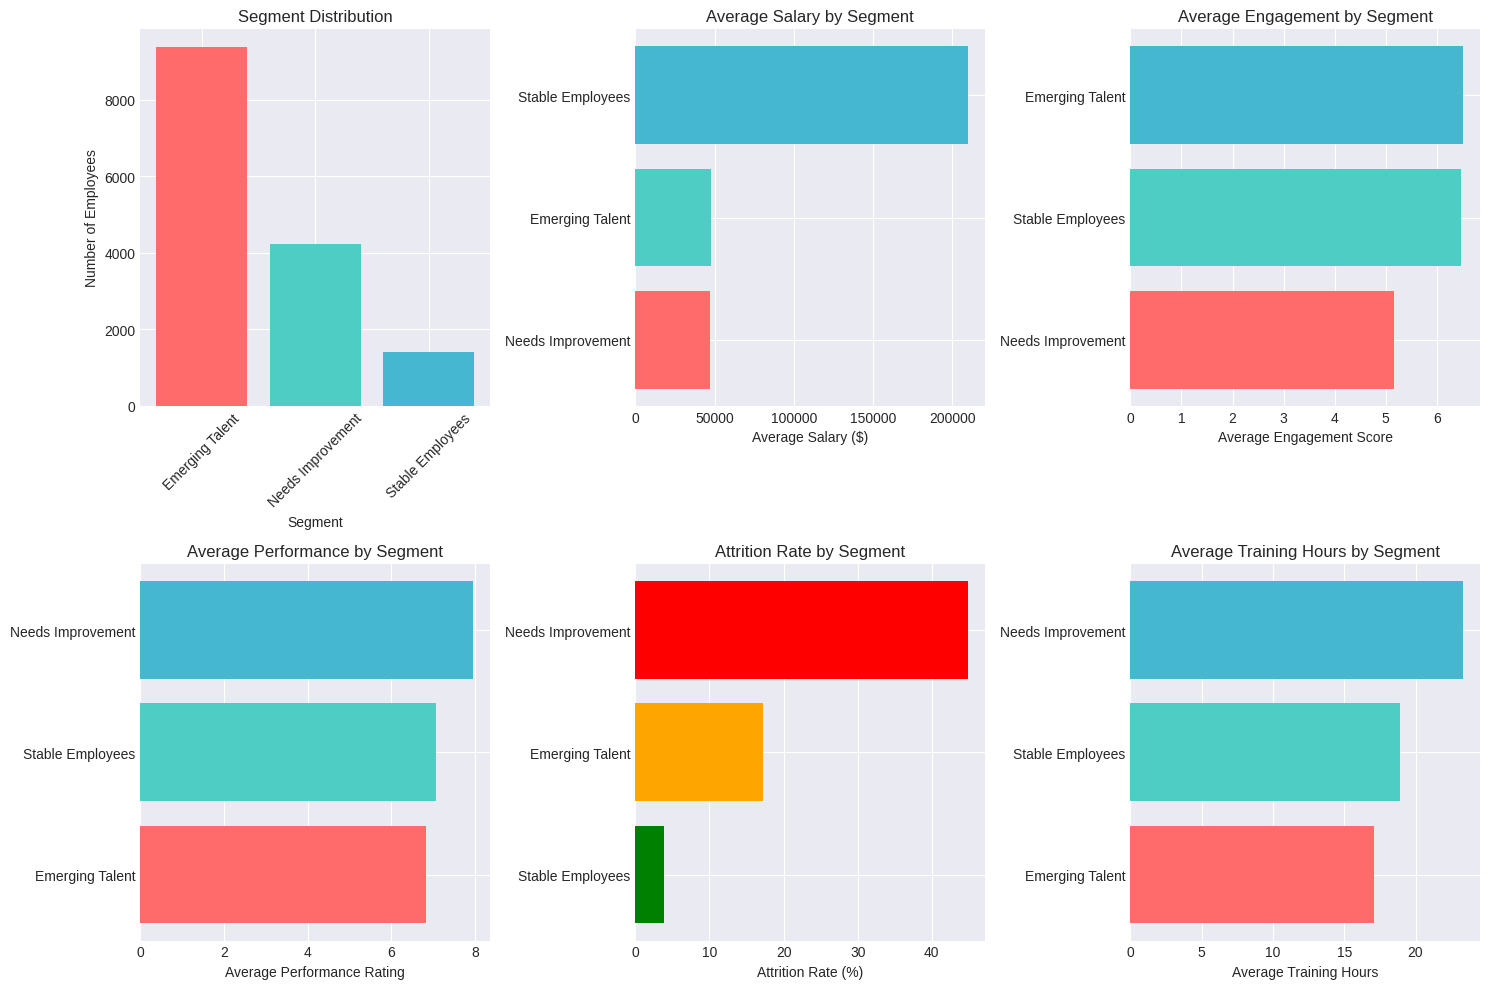

In [10]:
# Step 10: Segment Analysis

# Detailed Segment Analysis
segment_details = df_feat.groupby('Segment').agg({
    'Age': ['mean', 'std'],
    'Annual_Salary': ['mean', 'std'],
    'Company_Tenure': ['mean', 'std'],
    'Performance_Rating': ['mean', 'std'],
    'Employee_Satisfaction': ['mean', 'std'],
    'Overtime_Hours': ['mean', 'std'],
    'Training_Hours': ['mean', 'std'],
    'Absenteeism_Days': ['mean', 'std'],
    'Attrition': ['mean', 'std']
}).round(2)

print("Detailed Segment Analysis:")
display(segment_details)

# Segment Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

segments = df_feat['Segment'].unique()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# Segment Count
ax = axes[0, 0]
counts = df_feat['Segment'].value_counts()
ax.bar(counts.index, counts.values, color=colors[:len(counts)])
ax.set_title('Segment Distribution')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Employees')
ax.tick_params(axis='x', rotation=45)

# Average Salary by Segment
ax = axes[0, 1]
avg_salary = df_feat.groupby('Segment')['Annual_Salary'].mean().sort_values()
ax.barh(avg_salary.index, avg_salary.values, color=colors[:len(avg_salary)])
ax.set_title('Average Salary by Segment')
ax.set_xlabel('Average Salary ($)')

# Average Engagement by Segment
ax = axes[0, 2]
avg_engagement = df_feat.groupby('Segment')['Employee_Satisfaction'].mean().sort_values()
ax.barh(avg_engagement.index, avg_engagement.values, color=colors[:len(avg_engagement)])
ax.set_title('Average Engagement by Segment')
ax.set_xlabel('Average Engagement Score')

# Average Performance by Segment
ax = axes[1, 0]
avg_performance = df_feat.groupby('Segment')['Performance_Rating'].mean().sort_values()
ax.barh(avg_performance.index, avg_performance.values, color=colors[:len(avg_performance)])
ax.set_title('Average Performance by Segment')
ax.set_xlabel('Average Performance Rating')

# Attrition Rate by Segment
ax = axes[1, 1]
attrition_rate = df_feat.groupby('Segment')['Attrition'].mean() * 100
colors_attrition = ['green' if x < 15 else 'orange' if x < 25 else 'red' for x in attrition_rate.sort_values().values]
ax.barh(attrition_rate.sort_values().index, attrition_rate.sort_values().values, color=colors_attrition)
ax.set_title('Attrition Rate by Segment')
ax.set_xlabel('Attrition Rate (%)')

# Training Hours by Segment
ax = axes[1, 2]
avg_training = df_feat.groupby('Segment')['Training_Hours'].mean().sort_values()
ax.barh(avg_training.index, avg_training.values, color=colors[:len(avg_training)])
ax.set_title('Average Training Hours by Segment')
ax.set_xlabel('Average Training Hours')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HR_Analytics_Project/results/segment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()  # This will display in Colab

## Step 11: Attrition Risk Analysis
This cell assesses the attrition risk for each employee segment. It calculates a 'Risk Score' based on factors like attrition rate, employee satisfaction, overtime hours, and absenteeism days. The segments are then ranked by their risk scores, and the results are displayed and visualized. This analysis helps HR prioritize intervention strategies for segments with higher attrition risk. The risk analysis data and plot are saved to Google Drive.

Attrition Risk Analysis by Segment


,Attrition,Employee_Satisfaction,Overtime_Hours,Absenteeism_Days,Risk_Score
Segment,,,,,
Needs Improvement,0.45,5.15,226.88,2.84,8.24
Emerging Talent,0.17,6.52,189.61,2.37,5.71
Stable Employees,0.04,6.46,199.65,2.50,5.65


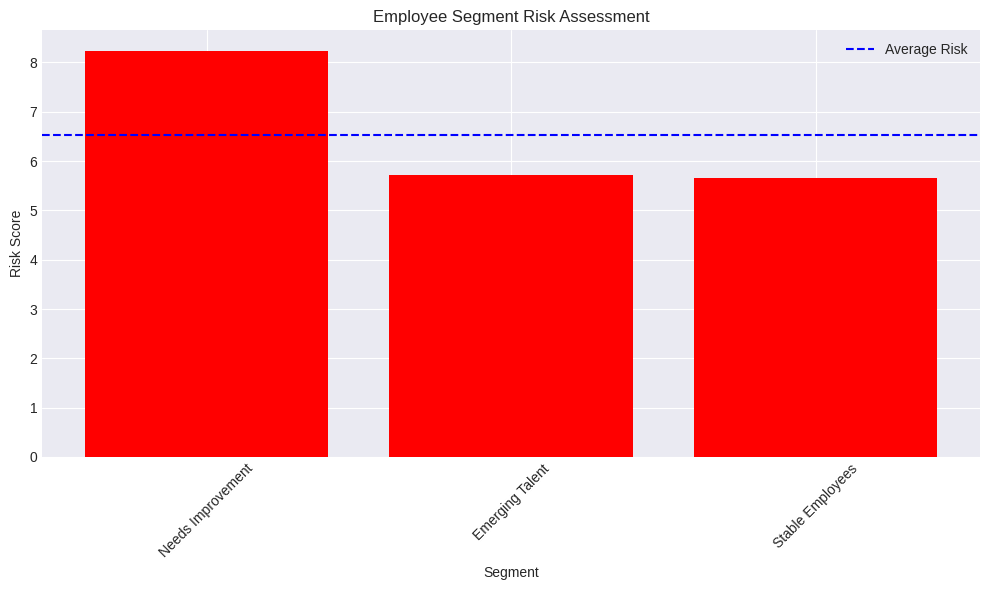

In [11]:
# Step 11: Attrition Risk Analysis

print("Attrition Risk Analysis by Segment")
print("=" * 50)

# Calculate risk scores
risk_df = df_feat.groupby('Segment').agg({
    'Attrition': 'mean',
    'Employee_Satisfaction': 'mean',
    'Overtime_Hours': 'mean',
    'Absenteeism_Days': 'mean'
}).round(2)

risk_df['Risk_Score'] = (
    risk_df['Attrition'] * 3 +
    (1 - risk_df['Employee_Satisfaction']/5) * 2 +
    risk_df['Overtime_Hours']/50 * 1.5 +
    risk_df['Absenteeism_Days']/20 * 1
).round(2)

risk_df = risk_df.sort_values('Risk_Score', ascending=False)
display(risk_df)

# Visualize Risk
plt.figure(figsize=(10, 6))
bars = plt.bar(risk_df.index, risk_df['Risk_Score'],
               color=['red' if x > 3 else 'orange' if x > 2 else 'green' for x in risk_df['Risk_Score']])
plt.title('Employee Segment Risk Assessment')
plt.xlabel('Segment')
plt.ylabel('Risk Score')
plt.axhline(y=risk_df['Risk_Score'].mean(), color='blue', linestyle='--', label='Average Risk')
plt.legend()
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HR_Analytics_Project/results/attrition_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()  # This will display in Colab

# Save risk analysis
risk_df.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/attrition_risk_analysis.csv')

## Step 12: HR Recommendations
Based on the detailed segment analysis and attrition risk assessment, this cell generates tailored HR recommendations for each identified employee segment. It outlines key issues specific to each segment (e.g., low engagement, high attrition risk) and proposes actionable HR strategies (e.g., engagement surveys, retention interviews, workload review). These recommendations are printed and saved to Google Drive.

In [12]:
# Step 10: HR Recommendations

hr_recommendations = pd.DataFrame({
    'Segment': [],
    'Key_Issues': [],
    'Recommended_Actions': []
})

for segment in df_feat['Segment'].unique():
    segment_data = df_feat[df_feat['Segment'] == segment]

    issues = []
    actions = []

    avg_engagement = segment_data['Employee_Satisfaction'].mean()
    avg_performance = segment_data['Performance_Rating'].mean()
    attrition_rate = segment_data['Attrition'].mean() * 100
    avg_overtime = segment_data['Overtime_Hours'].mean()
    avg_absenteeism = segment_data['Absenteeism_Days'].mean()
    avg_tenure = segment_data['Company_Tenure'].mean()

    if avg_engagement < 3.0:
        issues.append('Low engagement')
        actions.append('Conduct engagement survey and manager intervention')

    if avg_performance < 3.0:
        issues.append('Low performance')
        actions.append('Performance improvement plan and additional training')

    if attrition_rate > 20:
        issues.append('High attrition risk')
        actions.append('Retention interviews and compensation review')

    if avg_overtime > 10:
        issues.append('High overtime')
        actions.append('Review workload and resource allocation')

    if avg_absenteeism > 5:
        issues.append('High absenteeism')
        actions.append('Health and wellness programs')

    if avg_tenure < 2:
        issues.append('Short tenure')
        actions.append('Onboarding and mentoring programs')

    if avg_performance > 4.0 and avg_engagement > 4.0:
        actions.append('Leadership development and recognition programs')

    if not issues:
        issues.append('Stable performance')
        actions.append('Continue current HR practices')

    hr_recommendations.loc[len(hr_recommendations)] = [
        segment,
        '; '.join(issues[:3]),
        '; '.join(actions[:4])
    ]

print("HR Recommendations by Segment")
print("=" * 60)
print(hr_recommendations.to_string(index=False))

# Save recommendations
hr_recommendations.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/hr_recommendations.csv', index=False)

HR Recommendations by Segment
          Segment                         Key_Issues                                                                                                                    Recommended_Actions
  Emerging Talent                      High overtime                                               Review workload and resource allocation; Leadership development and recognition programs
Needs Improvement High attrition risk; High overtime Retention interviews and compensation review; Review workload and resource allocation; Leadership development and recognition programs
 Stable Employees                      High overtime                                               Review workload and resource allocation; Leadership development and recognition programs


## Step 13: SQL Queries for Database Integration
This cell generates a set of SQL queries designed for potential database integration. These queries cover various analytical needs, including segment distribution, departmental performance by segment, attrition risk, high performer analysis, and HR intervention priority. The queries are saved to an `.sql` file in Google Drive and also printed for review, facilitating easy transfer to a database environment.

In [13]:
# Step 13: SQL Queries

sql_queries = """
-- Employee Segmentation Analysis SQL Queries

-- 1. Segment Distribution
SELECT
    Segment,
    COUNT(*) as Employee_Count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as Percentage
FROM employee_segmentation
GROUP BY Segment
ORDER BY Employee_Count DESC;

-- 2. Department Performance by Segment
SELECT
    Department,
    Segment,
    COUNT(*) as Employee_Count,
    AVG(Annual_Salary) as Avg_Salary,
    AVG(Performance_Rating) as Avg_Performance,
    AVG(Employee_Satisfaction) as Avg_Engagement
FROM employee_segmentation
GROUP BY Department, Segment
ORDER BY Department, Segment;

-- 3. Attrition Risk Segments
SELECT
    Segment,
    ROUND(AVG(Attrition) * 100, 1) as Attrition_Rate,
    ROUND(AVG(Employee_Satisfaction), 2) as Avg_Engagement,
    ROUND(AVG(Overtime_Hours), 1) as Avg_Overtime,
    ROUND(AVG(Absenteeism_Days), 1) as Avg_Absenteeism
FROM employee_segmentation
GROUP BY Segment
ORDER BY Attrition_Rate DESC;

-- 4. High Performers Analysis
SELECT
    Department,
    COUNT(*) as High_Performers,
    ROUND(AVG(Annual_Salary), 0) as Avg_Salary,
    ROUND(AVG(Company_Tenure), 1) as Avg_Tenure
FROM employee_segmentation
WHERE Segment = 'High Performers'
GROUP BY Department
ORDER BY High_Performers DESC;

-- 5. HR Intervention Priority
SELECT
    Segment,
    COUNT(*) as At_Risk_Employees,
    ROUND(AVG(Attrition) * 100, 1) as Attrition_Rate,
    ROUND(AVG(Employee_Satisfaction), 2) as Engagement_Level,
    ROUND(AVG(Performance_Rating), 2) as Performance_Level
FROM employee_segmentation
WHERE Segment IN ('Retention Risk', 'Disengaged Employees', 'Needs Improvement')
GROUP BY Segment
ORDER BY Attrition_Rate DESC;
"""

with open('/content/drive/MyDrive/HR_Analytics_Project/sql/hr_analysis_queries.sql', 'w') as f:
    f.write(sql_queries)

print("SQL queries saved to Drive!")
print("\nSQL Queries:")
print(sql_queries)

SQL queries saved to Drive!

SQL Queries:

-- Employee Segmentation Analysis SQL Queries

-- 1. Segment Distribution
SELECT
    Segment,
    COUNT(*) as Employee_Count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as Percentage
FROM employee_segmentation
GROUP BY Segment
ORDER BY Employee_Count DESC;

-- 2. Department Performance by Segment
SELECT
    Department,
    Segment,
    COUNT(*) as Employee_Count,
    AVG(Annual_Salary) as Avg_Salary,
    AVG(Performance_Rating) as Avg_Performance,
    AVG(Employee_Satisfaction) as Avg_Engagement
FROM employee_segmentation
GROUP BY Department, Segment
ORDER BY Department, Segment;

-- 3. Attrition Risk Segments
SELECT
    Segment,
    ROUND(AVG(Attrition) * 100, 1) as Attrition_Rate,
    ROUND(AVG(Employee_Satisfaction), 2) as Avg_Engagement,
    ROUND(AVG(Overtime_Hours), 1) as Avg_Overtime,
    ROUND(AVG(Absenteeism_Days), 1) as Avg_Absenteeism
FROM employee_segmentation
GROUP BY Segment
ORDER BY Attrition_Rate DESC;

-- 4. High Pe

## Step 14: Save Model and Results
This cell is responsible for persistently storing all generated artifacts. It saves the processed `df_feat` DataFrame (with segment assignments), the `cluster_profile`, `segment_details`, and the trained machine learning model components (K-Means, scaler, PCA) using `pickle` for future use. All files are saved to their respective directories in Google Drive.

In [14]:
# Step 14: Save Model and Results

import pickle
import json

# Save the processed data
df_feat.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/employee_segmentation_results.csv', index=False)

# Save cluster profile
cluster_profile.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/cluster_profile.csv')

# Save segment details
segment_details.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/segment_details.csv')

# Save the model
model_data = {
    'kmeans': kmeans,
    'scaler': scaler,
    'features': clustering_features,
    'segment_names': segment_names,
    'pca': pca
}

with open('/content/drive/MyDrive/HR_Analytics_Project/models/employee_segmentation_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

In [15]:
# Step 14: Save Model and Results

import pickle
import json

# Save the processed data
df_feat.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/employee_segmentation_results.csv', index=False)

# Save cluster profile
cluster_profile.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/cluster_profile.csv')

# Save segment details
segment_details.to_csv('/content/drive/MyDrive/HR_Analytics_Project/results/segment_details.csv')

# Save the model
model_data = {
    'kmeans': kmeans,
    'scaler': scaler,
    'features': clustering_features,
    'segment_names': segment_names,
    'pca': pca
}

with open('/content/drive/MyDrive/HR_Analytics_Project/models/employee_segmentation_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

# Save metadata
metadata = {
    'total_employees': len(df_feat),
    'num_segments': optimal_k,
    'segments': segment_names,
    'features_used': clustering_features,
    'scaler_type': str(type(scaler)),
    'pca_explained_variance': pca.explained_variance_ratio_.tolist()
}

with open('/content/drive/MyDrive/HR_Analytics_Project/results/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("All results and models saved to Google Drive!")

All results and models saved to Google Drive!


## Step 15: Create Downloadable ZIP
This cell creates a comprehensive ZIP archive containing all project results, models, and SQL queries. This ZIP file makes it convenient to download all project outputs to your local machine or share them easily. The ZIP file is named `hr_analytics_results.zip` and is automatically downloaded after creation.

In [16]:
# Step 15: Create Downloadable ZIP

import zipfile
from google.colab import files

# Create ZIP file
with zipfile.ZipFile('hr_analytics_results.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add results folder
    results_dir = '/content/drive/MyDrive/HR_Analytics_Project/results/'
    for root, dirs, files_list in os.walk(results_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, f'results/{file}')

    # Add models folder
    models_dir = '/content/drive/MyDrive/HR_Analytics_Project/models/'
    for root, dirs, files_list in os.walk(models_dir):
        for file in files_list:
            file_path = os.path.join(root, file)
            zipf.write(file_path, f'models/{file}')

    # Add SQL queries
    sql_file = '/content/drive/MyDrive/HR_Analytics_Project/sql/hr_analysis_queries.sql'
    if os.path.exists(sql_file):
        zipf.write(sql_file, 'sql/hr_analysis_queries.sql')

print("ZIP file created: hr_analytics_results.zip")

# Download the ZIP file
files.download('hr_analytics_results.zip')

ZIP file created: hr_analytics_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 16: Final Summary
This final cell provides a concise summary of the entire HR Analytics project. It presents key findings, reiterates the segment distribution, and lists all the files that have been saved to Google Drive. It also displays a list of all charts generated throughout the project, offering a quick overview of the analytical outputs. This summary serves as a concluding report for the project.

In [17]:
# Step 16: Final Summary

print("EMPLOYEE SEGMENTATION & WORKFORCE INTELLIGENCE DASHBOARD")
print("=" * 60)
print("\nProject Summary:")
print(f"Total Employees Analyzed: {len(df_feat):,}")
print(f"Number of Segments Identified: {optimal_k}")
print("\nSegment Distribution:")
for cluster in sorted(df_feat['Cluster'].unique()):
    name = segment_names[cluster]
    count = len(df_feat[df_feat['Cluster'] == cluster])
    pct = count / len(df_feat) * 100
    print(f"  {name}: {count} employees ({pct:.1f}%)")

print("\nKey Findings:")
print("1. The employee workforce can be segmented into distinct groups with different engagement and performance profiles.")
print("2. Engagement and performance are key differentiators between segments.")
print("3. Certain segments show higher attrition risk requiring HR intervention.")
print("4. Department-level analysis reveals varying segment distributions.")
print("5. HR recommendations are provided for each segment to improve retention and engagement.")

print("\nFiles Saved to Google Drive:")
print("  - /content/drive/MyDrive/HR_Analytics_Project/results/")
print("  - /content/drive/MyDrive/HR_Analytics_Project/models/")
print("  - /content/drive/MyDrive/HR_Analytics_Project/sql/")

print("\n" + "=" * 60)
print("Project completed successfully!")

# Display all charts that were saved
print("\n\nAll Charts Generated in this Project:")
print("=" * 50)

charts = [
    'distribution_analysis.png',
    'department_analysis.png',
    'correlation_heatmap.png',
    'optimal_clusters_analysis.png',
    'pca_segmentation.png',
    'segment_analysis.png',
    'attrition_risk_analysis.png'
]

for chart in charts:
    print(f"- {chart}")

EMPLOYEE SEGMENTATION & WORKFORCE INTELLIGENCE DASHBOARD

Project Summary:
Total Employees Analyzed: 14,999
Number of Segments Identified: 4

Segment Distribution:
  Stable Employees: 563 employees (3.8%)
  Emerging Talent: 9368 employees (62.5%)
  Stable Employees: 844 employees (5.6%)
  Needs Improvement: 4224 employees (28.2%)

Key Findings:
1. The employee workforce can be segmented into distinct groups with different engagement and performance profiles.
2. Engagement and performance are key differentiators between segments.
3. Certain segments show higher attrition risk requiring HR intervention.
4. Department-level analysis reveals varying segment distributions.
5. HR recommendations are provided for each segment to improve retention and engagement.

Files Saved to Google Drive:
  - /content/drive/MyDrive/HR_Analytics_Project/results/
  - /content/drive/MyDrive/HR_Analytics_Project/models/
  - /content/drive/MyDrive/HR_Analytics_Project/sql/

Project completed successfully!


All